# Implement brightness enhancement of an RGB image using CUDA.

In [4]:
!wget -O image.jpg https://thumbs.dreamstime.com/b/pommes-vertes-et-rouges-moiti%C3%A9s-enti%C3%A8res-avec-des-feuilles-volant-dans-l-espace-sur-fond-vert-excellente-qualit%C3%A9-de-retouche-247971283.jpg

--2026-06-01 10:50:02--  https://thumbs.dreamstime.com/b/pommes-vertes-et-rouges-moiti%C3%A9s-enti%C3%A8res-avec-des-feuilles-volant-dans-l-espace-sur-fond-vert-excellente-qualit%C3%A9-de-retouche-247971283.jpg
Resolving thumbs.dreamstime.com (thumbs.dreamstime.com)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to thumbs.dreamstime.com (thumbs.dreamstime.com)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46471 (45K) [image/jpeg]
Saving to: ‘image.jpg’

image.jpg           100%[===================>]  45.38K  --.-KB/s    in 0s      

2026-06-01 10:50:02 (102 MB/s) - ‘image.jpg’ saved [46471/46471]



Image Shape: (877, 800, 3)


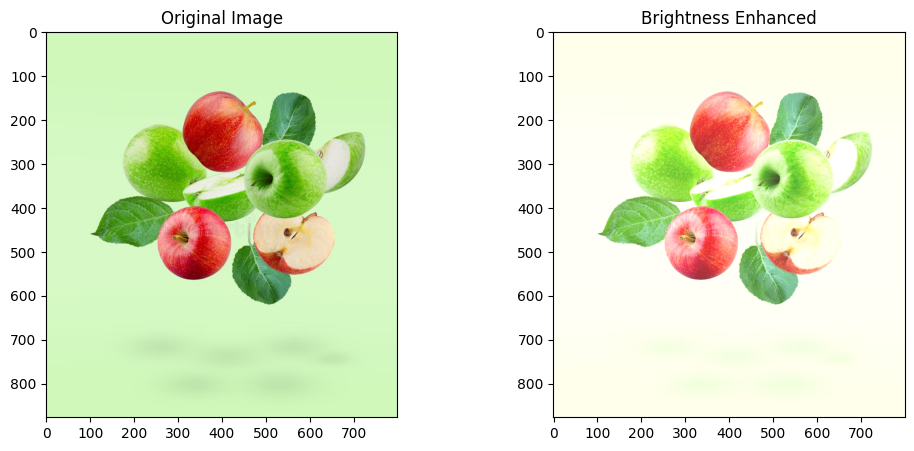

In [5]:
import cv2
import numpy as np
from numba import cuda
import matplotlib.pyplot as plt

# =====================================
# CUDA Kernel
# =====================================

@cuda.jit
def brightness_enhancement(img, output, brightness):

    x, y = cuda.grid(2)

    if x < img.shape[1] and y < img.shape[0]:

        for c in range(3):   # R,G,B channels

            value = img[y, x, c] + brightness

            if value > 255:
                value = 255

            output[y, x, c] = value

# =====================================
# Load RGB Image
# =====================================

img = cv2.imread("image.jpg")

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

height, width, channels = img.shape

print("Image Shape:", img.shape)

# =====================================
# Brightness Value
# =====================================

brightness = 50

# =====================================
# Allocate Output
# =====================================

output = np.zeros_like(img)

# =====================================
# Copy to GPU
# =====================================

d_img = cuda.to_device(img)
d_output = cuda.device_array_like(output)

# =====================================
# CUDA Configuration
# =====================================

threads_per_block = (16, 16)

blocks_per_grid = (
    (width + 15) // 16,
    (height + 15) // 16
)

# =====================================
# Launch Kernel
# =====================================

brightness_enhancement[
    blocks_per_grid,
    threads_per_block
](
    d_img,
    d_output,
    brightness
)

cuda.synchronize()

# =====================================
# Copy Back
# =====================================

output = d_output.copy_to_host()

# =====================================
# Display
# =====================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("Brightness Enhanced")

plt.show()